In [1]:
import sys
import os
import math
import glob
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sys.path.append('..')

# Project modules
from src.utility.config import (
    DEVICE, 
    CSV_DIR,
    BASELINE_MODEL_PATH, 
    QUANTIZED_MODELS, 
    EXPERIMENT_CONFIGS,
    DATASET_NAME
)
from src.utility.quantizer import Quantization
from src.utility.utils import get_data_loaders, get_model_size
from src.model import CNN
from src.layers import QuantizedLayerMixin
from src.evaluation.evaluate import evaluate
sns.set_theme(style="whitegrid")

In [2]:
# 1. Load Data
print("Lade Daten...")
train_loader, test_loader, num_classes = get_data_loaders()

# ---------------------------------------------------------
# A) BASELINE MODELL LADEN
# ---------------------------------------------------------
baseline_model = CNN(num_classes=num_classes).to(DEVICE)

# Liste möglicher Dateinamen (Config-Name vs. Alter Name)
possible_paths = [
    BASELINE_MODEL_PATH,                                  # Neu: mit Dataset Name
    os.path.join(os.path.dirname(BASELINE_MODEL_PATH), "baseline_float32.pt") # Alt: generisch
]

found_baseline = False
for path in possible_paths:
    if os.path.exists(path):
        baseline_model.load_state_dict(torch.load(path, map_location=DEVICE))
        baseline_model.convert_to_baseline() 
        baseline_model.eval()
        print(f"✅ Baseline geladen: {path}")
        found_baseline = True
        break

if not found_baseline:
    print(f"❌ FEHLER: Kein Baseline-Modell gefunden. Gesucht in: {possible_paths}")

# ---------------------------------------------------------
# B) QUANTISIERTES MODELL LADEN
# ---------------------------------------------------------
config_name = "Sym_INT8" 
quant_path = os.path.join(QUANTIZED_MODELS, f"model_{config_name}.pt")
found_quantized = False

quantized_model = CNN(num_classes=num_classes).to(DEVICE)

if os.path.exists(quant_path):
    quantized_model.load_state_dict(torch.load(quant_path, map_location=DEVICE))
    
    # Methode aus dem Namen ableiten (einfache Heuristik für das Notebook)
    method = 'symmetric' if 'Sym' in config_name else 'affine'
    bits = 4 if 'INT4' in config_name else 8
    
    # Wichtig: Schaltet das Modell in den Quantisierungs-Modus
    quantized_model.convert_to_quantized(method=method, bits=bits)
    quantized_model.eval()
    print(f"✅ Quantized Model geladen: {quant_path} (Method: {method}, Bits: {bits})")
    found_quantized = True
else:
    print(f"❌ Warnung: Quantisiertes Modell {config_name} nicht gefunden.")

Lade Daten...
✅ Baseline geladen: c:\Users\Dominic\Documents\ResearchProject\results\models\baseline_float32.pt
✅ Quantized Model geladen: c:\Users\Dominic\Documents\ResearchProject\results\quantized_models\model_Sym_INT8.pt (Method: symmetric, Bits: 8)


In [3]:
def visualize_comparison(model_f, model_q, test_loader, num_images=50):
    
    data_list, target_list = [], []
    for d, t in test_loader:
        data_list.append(d)
        target_list.append(t)
        if len(torch.cat(data_list)) >= num_images:
            break
            
    
    data = torch.cat(data_list)[:num_images].to(DEVICE)
    target = torch.cat(target_list)[:num_images].to(DEVICE)

    
    with torch.no_grad():
        out_f = model_f(data)
        out_q = model_q(data)
    pred_f = out_f.argmax(dim=1)
    pred_q = out_q.argmax(dim=1)

    
    cols = 8 
    rows = math.ceil(num_images / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.5 * rows))
    axes_flat = axes.flatten() 

    if hasattr(test_loader.dataset, 'classes'):
        class_names = test_loader.dataset.classes
    elif hasattr(test_loader.dataset, 'dataset') and hasattr(test_loader.dataset.dataset, 'classes'):
        class_names = test_loader.dataset.dataset.classes
    else:
        # Fallback falls keine Klassen namen da sind
        class_names = [str(i) for i in range(1000)]

    print(f"Zeige {num_images} Bilder. Legende: Grün=Korrekt, Rot=Falsch, Orange=Quantisierung weicht ab")

    for i in range(num_images):
        ax = axes_flat[i]
       
        img = data[i].cpu().permute(1, 2, 0).numpy()
        img = img * 0.5 + 0.5 
        img = np.clip(img, 0, 1) 

        ax.imshow(img)
        
        p_q_idx = pred_q[i].item()
        p_f_idx = pred_f[i].item()
        real_idx = target[i].item()
        
        name_q = class_names[p_q_idx]
        name_real = class_names[real_idx]

        is_correct = (p_q_idx == real_idx)
        has_changed = (p_q_idx != p_f_idx) 

        if has_changed:
            color = 'orange'
            
            title_text = f"Q: {name_q}\n(F: {class_names[p_f_idx]})"
        else:
            color = 'green' if is_correct else 'red'
            title_text = f"Pred: {name_q}\nReal: {name_real}"

        ax.set_title(title_text, color=color, fontsize=10, fontweight='bold')
        ax.axis('off')
        
    for j in range(num_images, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

In [4]:
def assess_classification_performance(model, data_loader, device, model_name="Model"):
   
    model.eval() 
    
    all_targets = []
    all_predictions = []
    
    print(f"--- Starte Assessment für: {model_name} ---")
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    acc = accuracy_score(all_targets, all_predictions)
    
    error_rate = 1.0 - acc
    
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    
    print("\n>>> Detailed Classification Report (Precision, Recall, F-Measure):")
    print(classification_report(all_targets, all_predictions, digits=4))
    
    TOP_N = 15 
    
    from collections import Counter
    class_counts = Counter(all_targets)
    
    top_classes = [cls for cls, count in class_counts.most_common(TOP_N)]
    
    mask = [t in top_classes and p in top_classes for t, p in zip(all_targets, all_predictions)]
    
    subset_targets = [t for t, m in zip(all_targets, mask) if m]
    subset_preds = [p for p, m in zip(all_predictions, mask) if m]
    
    if len(subset_targets) > 0:
        cm = confusion_matrix(subset_targets, subset_preds, labels=top_classes)

        plt.figure(figsize=(10, 8))
        try:
            import seaborn as sns
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=top_classes, yticklabels=top_classes)
        except ImportError:
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_classes)
            disp.plot(cmap='Blues', values_format='d', ax=plt.gca())

        plt.title(f"Confusion Matrix (Top {TOP_N} Frequent Classes) - {model_name}")
        plt.xlabel('Predicted Class')
        plt.ylabel('True Class')
        plt.show()
    else:
        print("Zu wenige Datenpunkte für das Subset-Plotting.")

    return acc

In [5]:
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    return np.array(all_labels), np.array(all_preds)

# Predictions holen
print("Generiere Vorhersagen für Baseline...")
y_true, y_pred_base = get_predictions(baseline_model, test_loader)

print("Generiere Vorhersagen für Quantized...")
_, y_pred_quant = get_predictions(quantized_model, test_loader)

Generiere Vorhersagen für Baseline...
Generiere Vorhersagen für Quantized...


In [6]:
def plot_layer_weight_ranges(model):
    layer_names = []
    weight_data = []
    
    for name, module in model.named_modules():
        # Wir schauen uns Conv2d und Linear Layer an
        if isinstance(module, (torch.nn.Conv2d, torch.nn.Linear)):
            # Gewichte holen und flach machen
            w = module.weight.detach().cpu().numpy().flatten()
            
            layer_names.append(name)
            weight_data.append(w)
            
    # Plot
    plt.figure(figsize=(14, 6))
    plt.boxplot(weight_data, labels=layer_names, showfliers=False) # showfliers=False blendet extreme Outlier aus für bessere Lesbarkeit
    
    plt.title("Gewichts-Verteilung pro Layer (Range)")
    plt.ylabel("Gewichtswert")
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', alpha=0.5)
    
    # Rote Linie bei 0
    plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()

In [7]:
def plot_weight_distribution(model, layer_name, title_suffix=""):
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, QuantizedLayerMixin):
            
            weights = module.weight.detach().cpu()
            
            w_fake, _ = Quantization.quantize_with_params(
                module.weight, 
                module.weight_scale, 
                module.weight_zero_point,
                module.quant_method,
                module.num_bits
            )
            w_fake = w_fake.detach().cpu()

            plt.figure(figsize=(12, 5))

            plt.subplot(1, 2, 1)
            sns.histplot(weights.flatten().numpy(), bins=50, kde=True, color='blue')
            plt.title(f"{layer_name} - Original Float32")
            plt.xlabel("Weight Value")
            
            plt.subplot(1, 2, 2)

            sns.histplot(w_fake.flatten().numpy(), bins=50, kde=False, color='red')
            plt.title(f"{layer_name} - {title_suffix} (Simulated)")
            plt.xlabel("Weight Value")
            
            plt.tight_layout()
            plt.show()
            return
    print(f"Layer {layer_name} nicht gefunden oder nicht quantisierbar.")

--- Vergleiche Accuracy pro Klasse ---


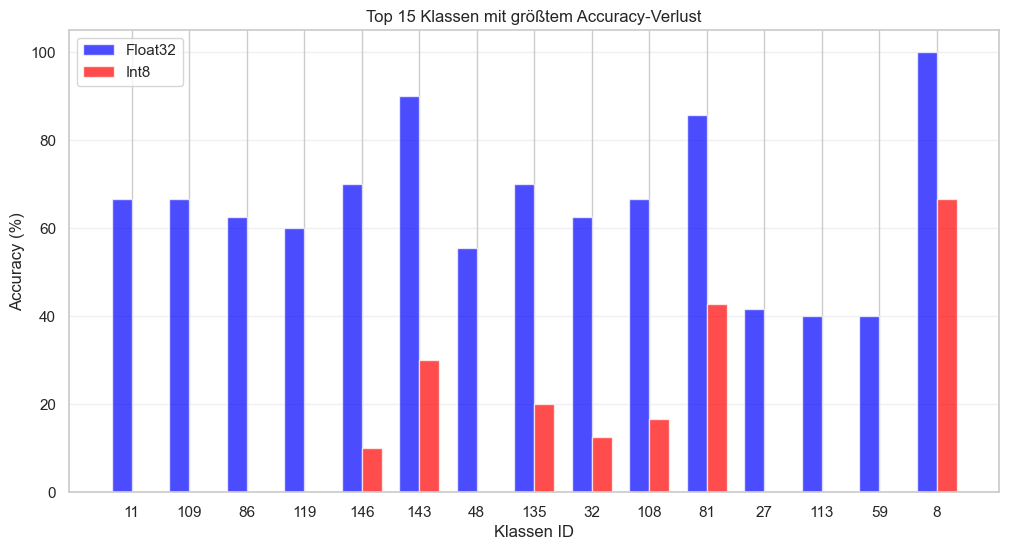

In [8]:
def plot_per_class_accuracy_comparison(model_float, model_quant, loader, class_names=None):
    model_float.eval()
    model_quant.eval()
    
    correct_float = {}
    correct_quant = {}
    total_count = {}
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            
            # Float Preds
            out_f = model_float(data)
            pred_f = out_f.argmax(dim=1)
            
            # Quant Preds
            out_q = model_quant(data)
            pred_q = out_q.argmax(dim=1)
            
            for i in range(len(target)):
                label = target[i].item()
                total_count[label] = total_count.get(label, 0) + 1
                
                if pred_f[i] == label:
                    correct_float[label] = correct_float.get(label, 0) + 1
                
                if pred_q[i] == label:
                    correct_quant[label] = correct_quant.get(label, 0) + 1

    classes = sorted(total_count.keys())
    acc_f = [correct_float.get(c, 0) / total_count[c] * 100 for c in classes]
    acc_q = [correct_quant.get(c, 0) / total_count[c] * 100 for c in classes]
    

    diffs = [f - q for f, q in zip(acc_f, acc_q)]
    
    sorted_indices = np.argsort(diffs)[::-1][:15] # Top 15 Drops
    
    top_classes = [str(c) for c in np.array(classes)[sorted_indices]]
    top_acc_f = np.array(acc_f)[sorted_indices]
    top_acc_q = np.array(acc_q)[sorted_indices]
    
    x = np.arange(len(top_classes))
    width = 0.35
    
    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, top_acc_f, width, label='Float32', color='blue', alpha=0.7)
    plt.bar(x + width/2, top_acc_q, width, label='Int8', color='red', alpha=0.7)
    
    plt.xlabel('Klassen ID')
    plt.ylabel('Accuracy (%)')
    plt.title('Top 15 Klassen mit größtem Accuracy-Verlust')
    plt.xticks(x, top_classes)
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

print("--- Vergleiche Accuracy pro Klasse ---")
plot_per_class_accuracy_comparison(baseline_model, quantized_model, test_loader)

Lade Ergebnisse aus: c:\Users\Dominic\Documents\ResearchProject\results\csv\quantization_results_POKEMON.csv


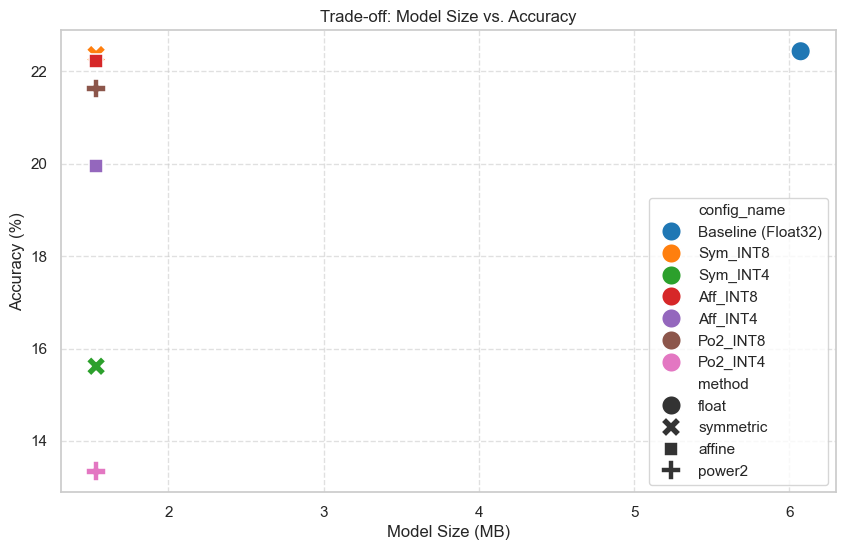

,config_name,accuracy,model_size_mb,inference_time,drop_percentage
0,Baseline (Float32),22.434018,6.072220,4.188150,0.000000
1,Sym_INT8,22.360704,1.533902,6.968574,0.073314
2,Sym_INT4,15.615836,1.533902,7.200142,6.818182
3,Aff_INT8,22.214076,1.533902,6.997411,0.219941
4,Aff_INT4,19.941349,1.533902,6.799158,2.492669
5,Po2_INT8,21.627566,1.533902,6.817305,0.806452
6,Po2_INT4,13.343109,1.533902,6.965679,9.090909


In [9]:
csv_files = glob.glob(os.path.join(CSV_DIR, "quantization_results_*.csv"))
if csv_files:
    latest_csv = max(csv_files, key=os.path.getctime)
    print(f"Lade Ergebnisse aus: {latest_csv}")
    df_results = pd.read_csv(latest_csv)
    
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df_results, 
        x='model_size_mb', 
        y='accuracy', 
        hue='config_name', 
        style='method', 
        s=200, # Basisgröße
        palette='tab10'
    )

    plt.title("Trade-off: Model Size vs. Accuracy")
    plt.xlabel("Model Size (MB)")
    plt.ylabel("Accuracy (%)")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()
    
    display(df_results[['config_name', 'accuracy', 'model_size_mb', 'inference_time', 'drop_percentage']])

else:
    print("Keine Ergebnis-CSV gefunden. Hast du main_experiment.py schon komplett laufen lassen?")

Lade Sensitivitäts-Daten: c:\Users\Dominic\Documents\ResearchProject\results\csv\sensitivity_analysis.csv


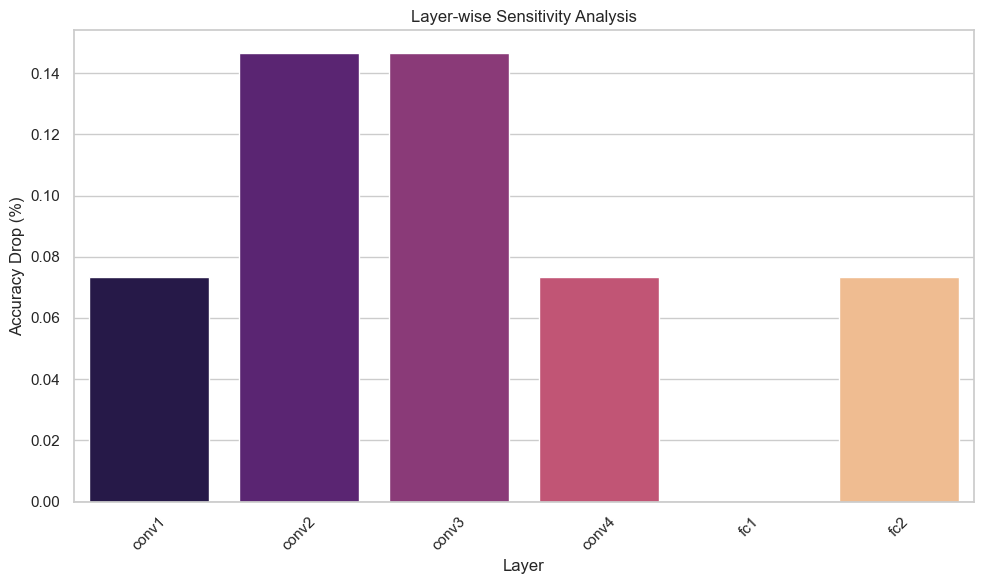

,layer_name,accuracy,drop
1,conv2,22.287390,0.146628
2,conv3,22.287390,0.146628
0,conv1,22.360704,0.073314
3,conv4,22.360704,0.073314
5,fc2,22.360704,0.073314
4,fc1,22.434018,0.000000


In [10]:
csv_files = glob.glob(os.path.join(CSV_DIR, "sensitivity_*.csv"))

if csv_files:
    # Neueste Datei nehmen
    latest_csv = max(csv_files, key=os.path.getctime)
    print(f"Lade Sensitivitäts-Daten: {latest_csv}")
    
    df_sens = pd.read_csv(latest_csv)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_sens, x='layer_name', y='drop', hue='layer_name', legend=False, palette='magma')
    
    plt.title("Layer-wise Sensitivity Analysis")
    plt.ylabel("Accuracy Drop (%)")
    plt.xlabel("Layer")
    plt.xticks(rotation=45)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    
    # Tabelle anzeigen
    display(df_sens.sort_values(by='drop', ascending=False))
else:
    print("Keine Sensitivitäts-CSV gefunden. Bitte erst main_experiment.py ausführen.")

--- Analyse der Gewichtsverteilung (Float Model) ---


C:\Users\Dominic\AppData\Local\Temp\ipykernel_122040\2549143981.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(weight_data, labels=layer_names, showfliers=False) # showfliers=False blendet extreme Outlier aus für bessere Lesbarkeit


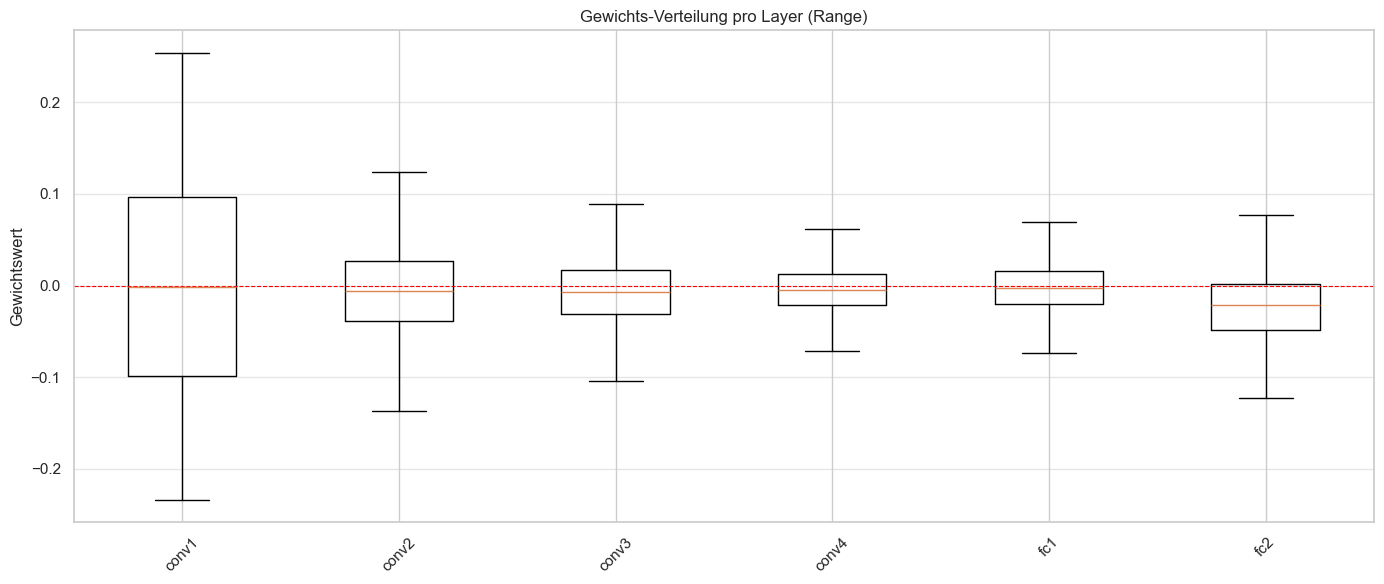

In [11]:
print("--- Analyse der Gewichtsverteilung (Float Model) ---")
# Am besten am Baseline-Modell ausführen, um die "echten" Ranges zu sehen
plot_layer_weight_ranges(baseline_model)

--- Visualisierung für Sym_INT8 ---


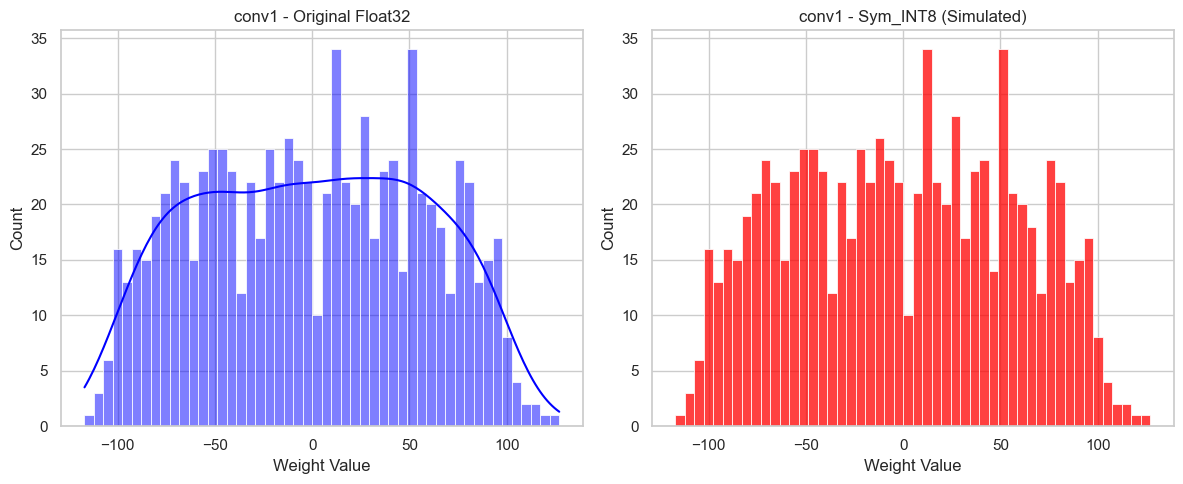

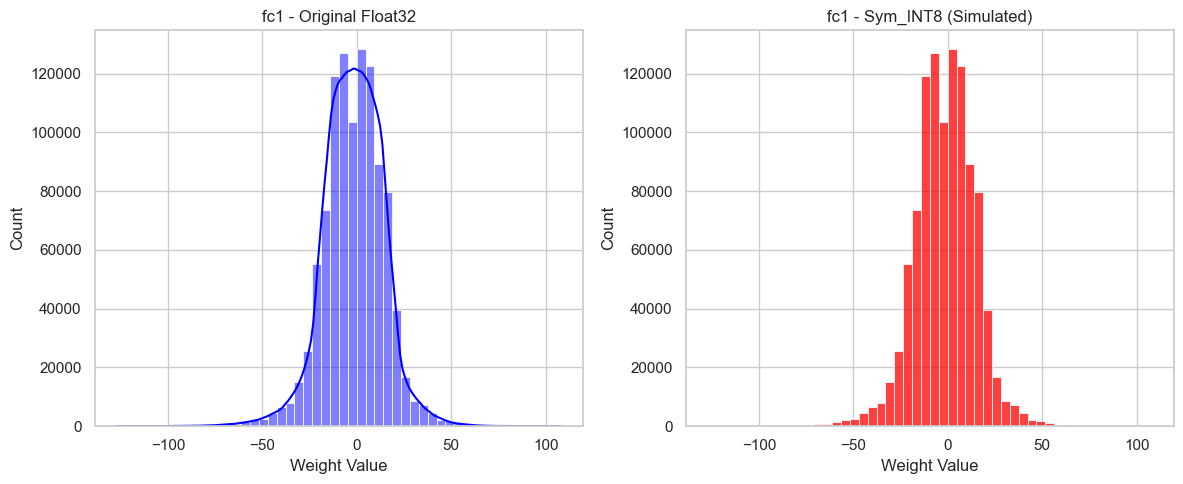

In [ ]:
if found_quantized:
    print(f"--- Visualisierung für {config_name} ---")
    plot_weight_distribution(quantized_model, "conv1", title_suffix=config_name)
    plot_weight_distribution(quantized_model, "conv2", title_suffix=config_name)
    plot_weight_distribution(quantized_model, "conv3", title_suffix=config_name)
    plot_weight_distribution(quantized_model, "conv4", title_suffix=config_name)

    plot_weight_distribution(quantized_model, "fc1", title_suffix=config_name)
    plot_weight_distribution(quantized_model, "fc2", title_suffix=config_name)

--- Starte Assessment für: Baseline (Float32) ---
Accuracy:   0.2243 (22.43%)
Error Rate: 0.7757 (77.57%)

>>> Detailed Classification Report (Precision, Recall, F-Measure):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         9
           1     0.2000    0.3333    0.2500         6
           2     0.0000    0.0000    0.0000         5
           3     0.0000    0.0000    0.0000         9
           4     1.0000    0.1429    0.2500        14
           5     0.0000    0.0000    0.0000         9
           6     0.1311    0.8000    0.2254        10
           7     1.0000    0.2500    0.4000         4
           8     0.3750    1.0000    0.5455         6
           9     0.0000    0.0000    0.0000         6
          10     0.8000    0.8000    0.8000        10
          11     0.6667    0.6667    0.6667         3
          12     0.2632    0.6250    0.3704         8
          13     0.1429    0.6667    0.2353         9
          14   

c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

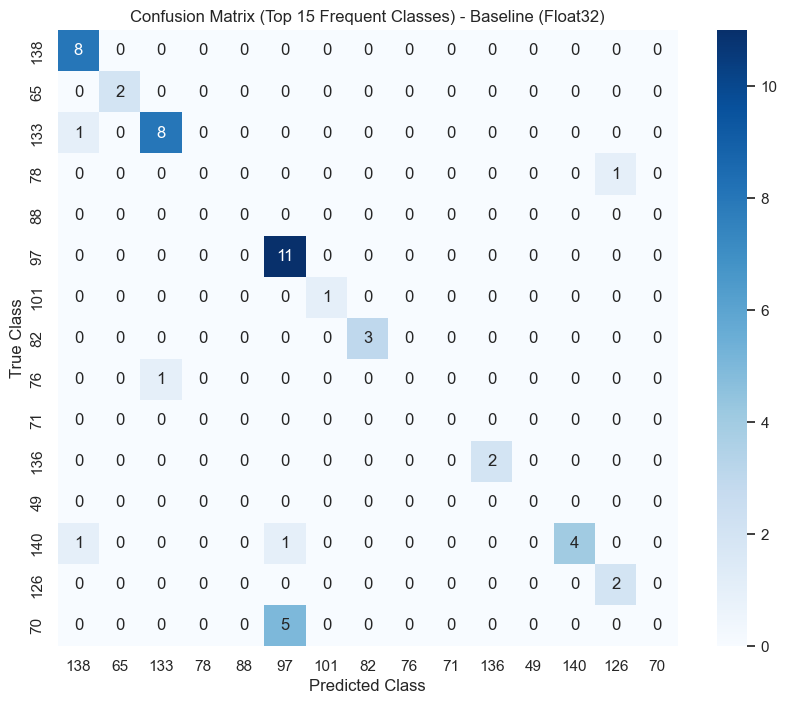

--- Starte Assessment für: Quantized (Sym_INT8) ---
Accuracy:   0.1283 (12.83%)
Error Rate: 0.8717 (87.17%)

>>> Detailed Classification Report (Precision, Recall, F-Measure):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         9
           1     0.0000    0.0000    0.0000         6
           2     0.0000    0.0000    0.0000         5
           3     0.0000    0.0000    0.0000         9
           4     0.0000    0.0000    0.0000        14
           5     0.0000    0.0000    0.0000         9
           6     0.2609    0.6000    0.3636        10
           7     0.0000    0.0000    0.0000         4
           8     0.4444    0.6667    0.5333         6
           9     0.0000    0.0000    0.0000         6
          10     0.8333    0.5000    0.6250        10
          11     0.0000    0.0000    0.0000         3
          12     0.3333    0.3750    0.3529         8
          13     0.1905    0.4444    0.2667         9
          14 

c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

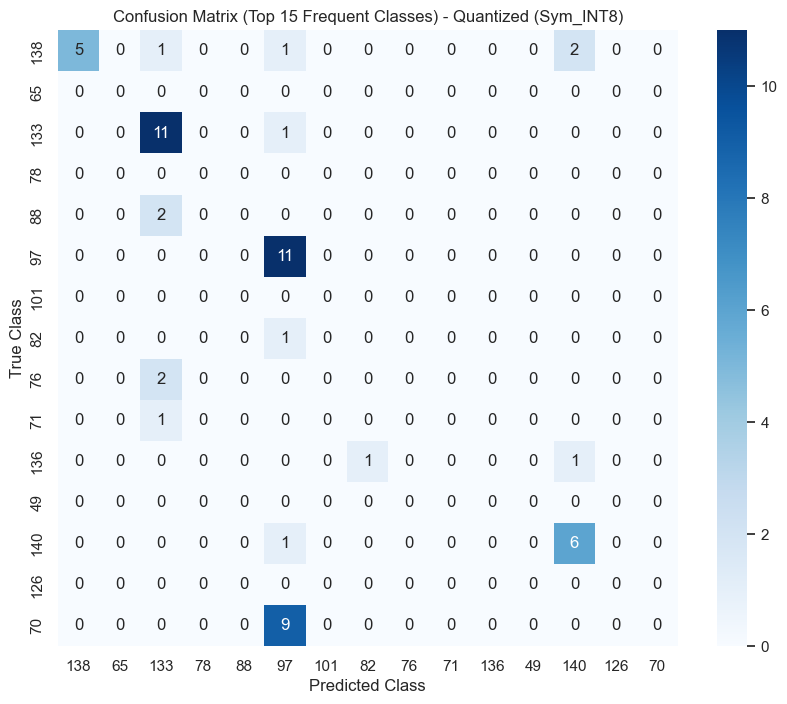


FAZIT: Accuracy Drop: 9.60% (Float: 22.43% -> Int8: 12.83%)


In [13]:
acc_base = assess_classification_performance(
    baseline_model, 
    test_loader, 
    DEVICE, 
    model_name="Baseline (Float32)"
)

acc_quant = assess_classification_performance(
    quantized_model, 
    test_loader, 
    DEVICE, 
    model_name=f"Quantized ({config_name})"
)

diff = acc_base - acc_quant
print("\n==================================================")
print(f"FAZIT: Accuracy Drop: {diff*100:.2f}% (Float: {acc_base*100:.2f}% -> Int8: {acc_quant*100:.2f}%)")
print("==================================================")

Zeige 50 Bilder. Legende: Grün=Korrekt, Rot=Falsch, Orange=Quantisierung weicht ab


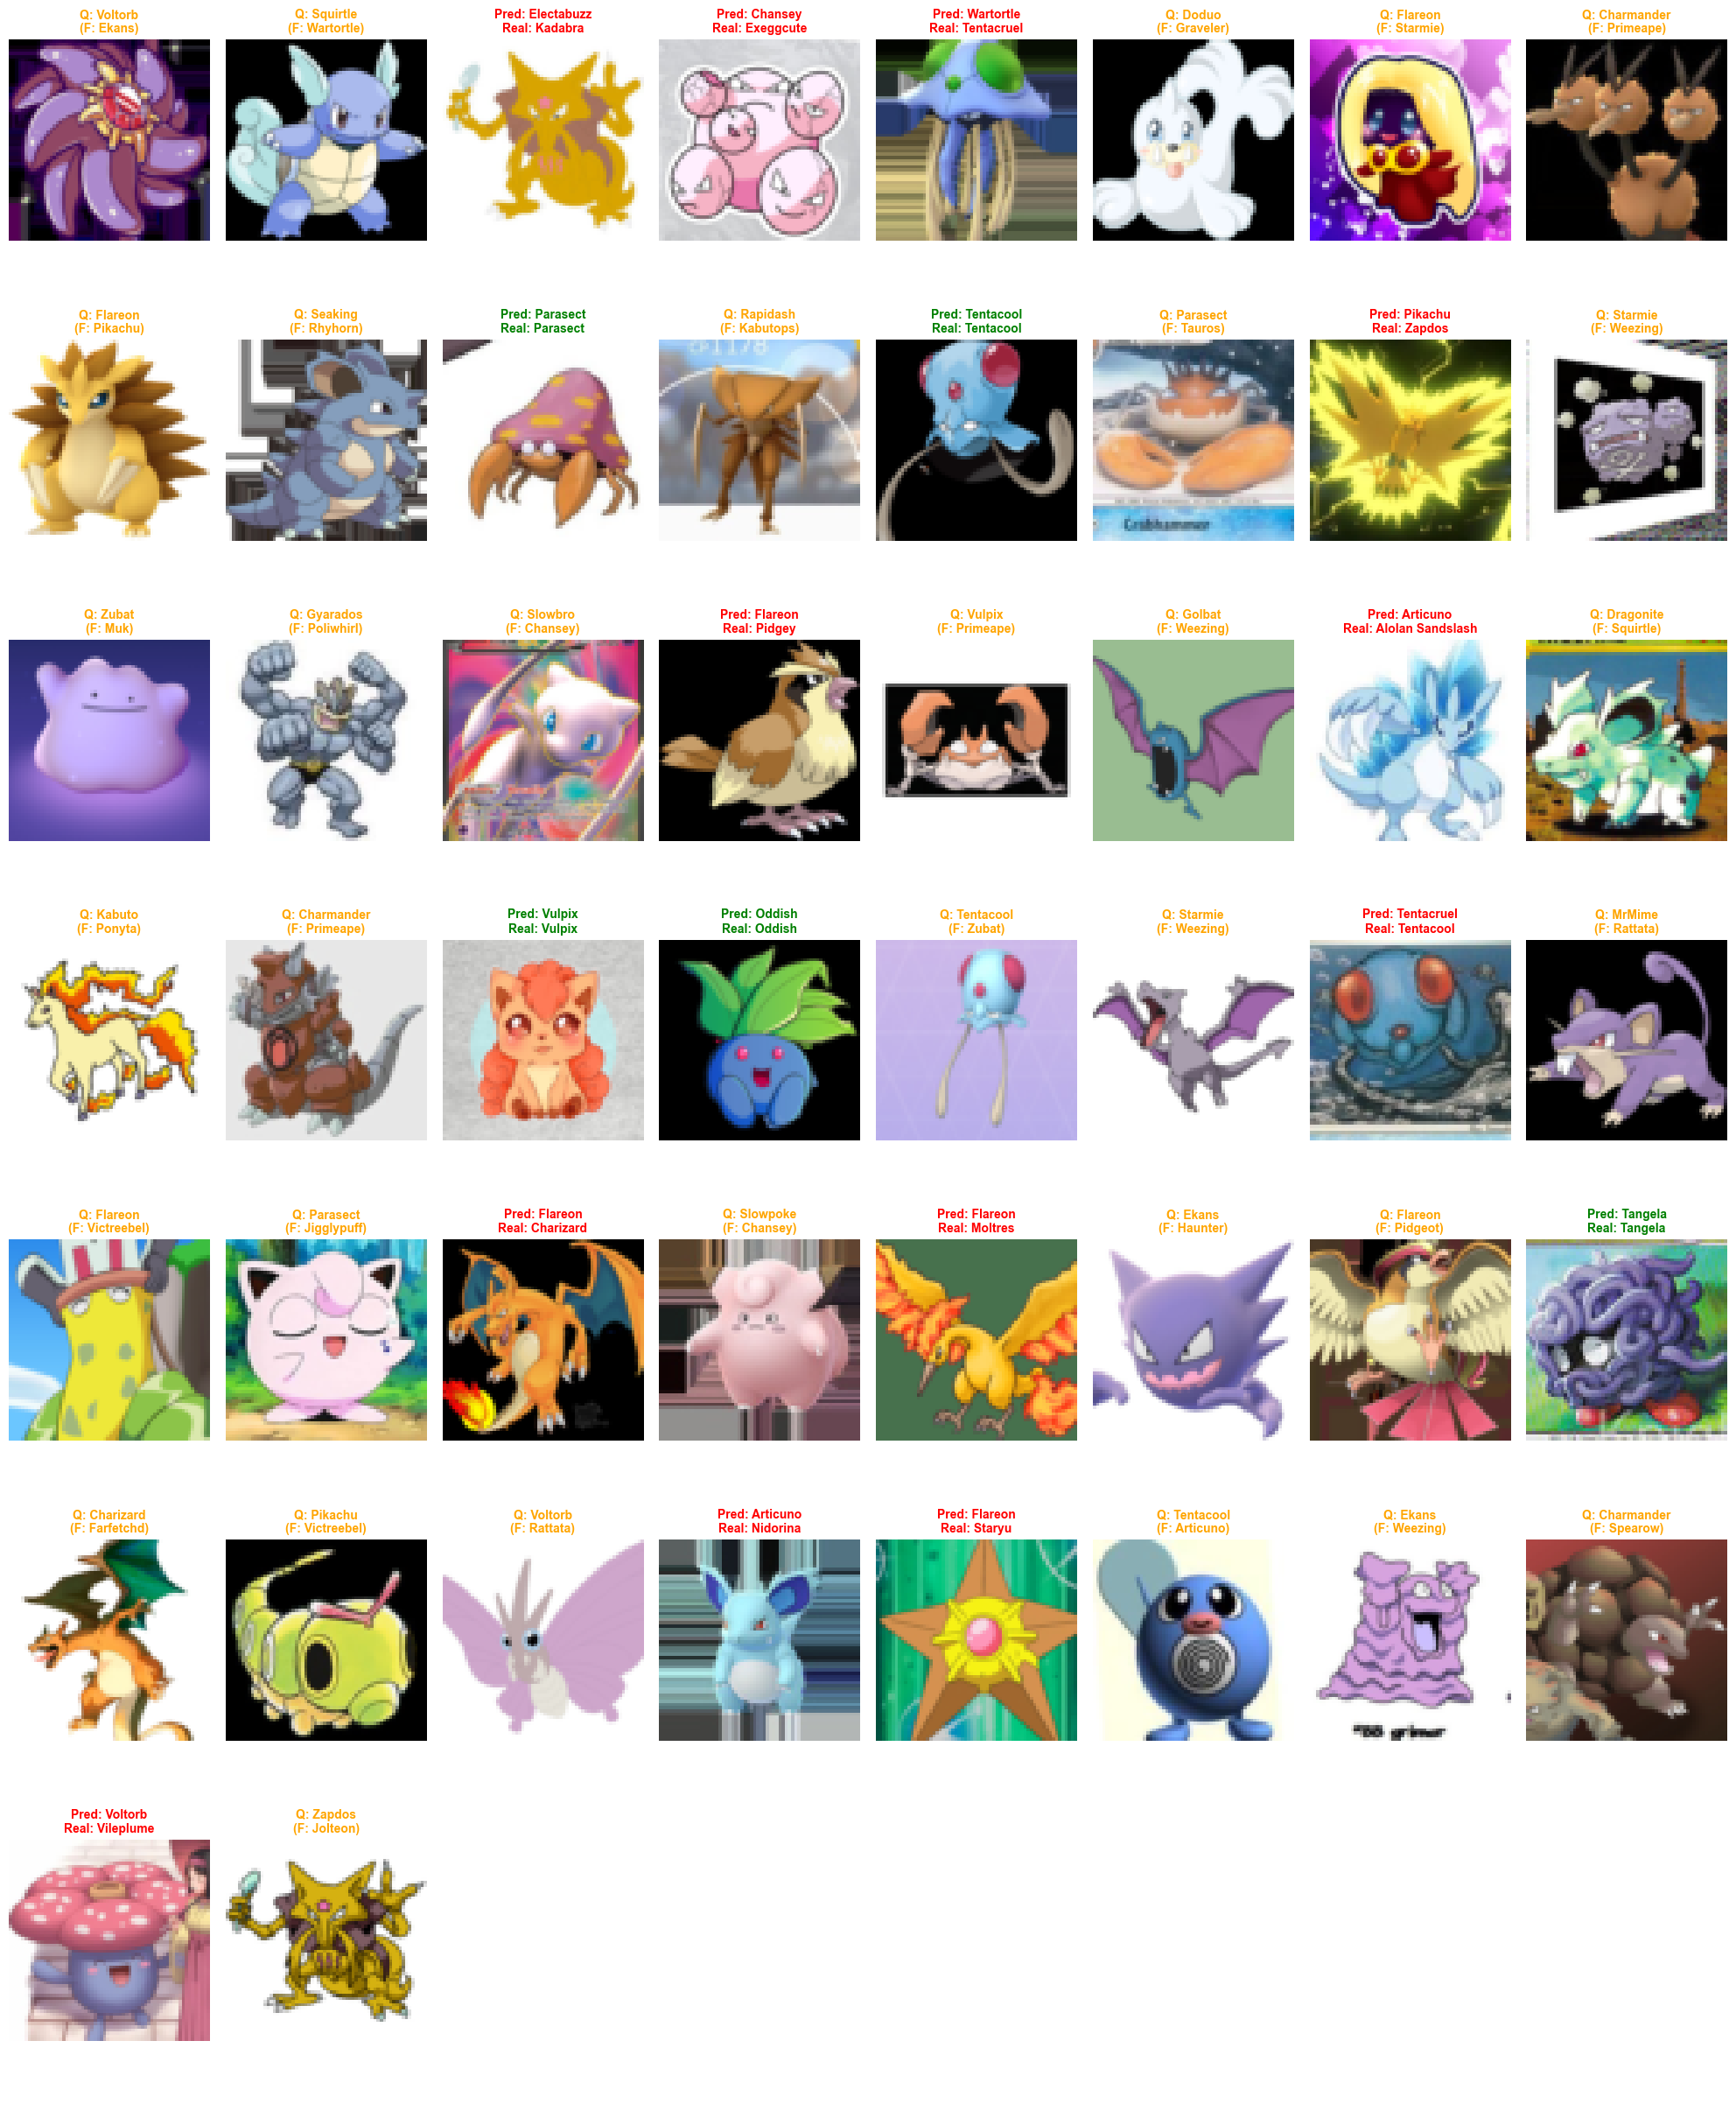

In [14]:

visualize_comparison(model_f=baseline_model, model_q=quantized_model, test_loader=test_loader, num_images=50)


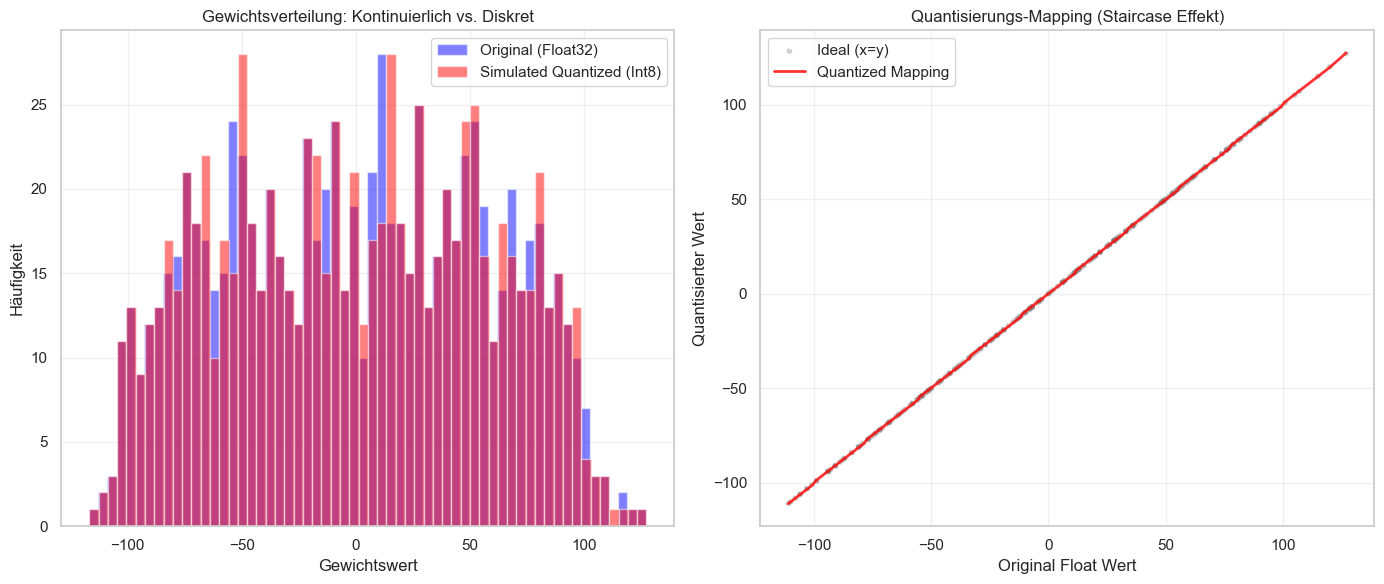

In [15]:


weights_floats = quantized_model.conv1.weight.data.clone().cpu()

weights_dequant, _, _, _ = Quantization.affine_quantization(weights_floats, num_bits=8)


flat_float = weights_floats.view(-1).numpy()
flat_dequant = weights_dequant.view(-1).numpy()

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.hist(flat_float, bins=60, color='blue', alpha=0.5, label="Original (Float32)")
plt.hist(flat_dequant, bins=60, color='red', alpha=0.5, label="Simulated Quantized (Int8)")

plt.title("Gewichtsverteilung: Kontinuierlich vs. Diskret")
plt.xlabel("Gewichtswert")
plt.ylabel("Häufigkeit")
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1,2,2)


num_samples = 300
if len(flat_float) > num_samples:
    rand_idx = np.random.choice(len(flat_float), num_samples, replace=False)

    subset_idx = rand_idx[np.argsort(flat_float[rand_idx])]
else:
    subset_idx = np.argsort(flat_float)

plt.scatter(flat_float[subset_idx], flat_float[subset_idx], 
            color='gray', alpha=0.3, label="Ideal (x=y)", s=10, linestyle='--')
            
plt.plot(flat_float[subset_idx], flat_dequant[subset_idx], 
            color='red', alpha=0.8, label="Quantized Mapping", linewidth=2)

plt.title("Quantisierungs-Mapping (Staircase Effekt)")
plt.xlabel("Original Float Wert")
plt.ylabel("Quantisierter Wert")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()